# Disentangling Offence Composition from Differential Response in Toronto Hate-Crime Arrests

**Question.** Religious-bias hate crimes show a lower raw arrest rate than other hate crimes. Is that gap explained by offence composition (religious-bias crimes skewing toward hard-to-clear property mischief), or does it persist within offence types?

**Data.** Toronto Police Service, Hate Crime Open Data.

**Scope & limits.** This analyzes incidents police classified as hate crimes, and treats arrest as the outcome. Arrest is an enforcement action, not a measure of justice, and the dataset reflects police recording and response — not hate crime incidence. Findings describe how police responded to recorded incidents, nothing broader.

## 1. Load and verify the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('../data/raw/hate_crime_raw.csv')
df.shape

(2041, 25)

In [2]:
df['ARREST_MADE'].value_counts()

ARREST_MADE
No     1588
Yes     453
Name: count, dtype: int64

In [3]:
df['PRIMARY_OFFENCE'].value_counts()

PRIMARY_OFFENCE
Mischief Under $5000                                              931
Assault                                                           395
Uttering Threats - Bodily Harm                                    222
Assault With a Weapon                                             103
Criminal Harassment                                                95
Mischief Interfere With Property                                   56
Mischief To Religious Property, Educational Institutions, Etc.     54
Harassing Communications                                           45
Disturbing Religious Worship Or Certain Meetings                   20
Other                                                              20
Assault Causing Bodily Harm                                        15
Indecent Communications                                            13
Wilful Promotion of Hatred                                         11
Uttering Threats - Property                                        10
Thef

## 2. Build bias flags and the arrest target

Each bias axis is encoded as its own binary flag rather than collapsed into one column, because (a) incidents can be targeted on multiple axes at once, and (b) the bias columns encode which axis of the victim's identity was targeted, not a single property of the crime. A `0` is meaningful — "not recorded on this axis" — not missing-at-random.

This analysis focuses on religion (n=968) and race (n=609), the only axes with enough incidents to support estimates; the others (gender 112, language 4, etc.) are too sparse.

In [4]:
df['religion_bias'] = (df['RELIGION_BIAS'].notna() &
                       (df['RELIGION_BIAS'].str.strip().str.upper() != 'NO')).astype(int)
df['race_bias'] = (df['RACE_BIAS'].notna() &
                   (df['RACE_BIAS'].str.strip().str.upper() != 'NO')).astype(int)
df['arrest'] = (df['ARREST_MADE'] == 'Yes').astype(int)
df[['religion_bias','race_bias','arrest']].sum()

religion_bias    968
race_bias        609
arrest           453
dtype: int64

## 3. Group offence types

`PRIMARY_OFFENCE` has 30 offences, many with only 1-2 incidents. They are collapsed into four behavioral categories, grouped by the factor that actually drives arrest likelihood: whether the offence tends to have an identifiable suspect. This is the confound being controlled for.

| Category | Logic | Examples |
|---|---|---|
| **mischief** | Property crime, often no suspect present | Mischief (all), Arson, Theft |
| **violent** | Suspect frequently identified | Assault (all forms), Robbery, Murder, Firearms |
| **threats** | Often a known perpetrator | Uttering Threats, Criminal Harassment, Harassing Communications |
| **propaganda** | Speech / ideology offences | Promotion & Incitement of Hatred, Advocating Genocide |

**Documented judgment calls** (grouping by behavior):
- **Criminal Harassment → threats.** Per *Criminal Code* [s.264](https://laws-lois.justice.gc.ca/eng/acts/c-46/section-264.html), this consists of following, repeated contact, watching/besetting, and fear-inducing conduct — behaviorally a threat-type offence, typically with a known perpetrator.
- **Disturbing Religious Worship → propaganda.** An ideologically-motivated disruption of a religious gathering, not property damage.
- **Causing a Disturbance → threats.** A public-order offence, not violence.
- **Fail To Comply Probation (n=1) → mischief**, as nearest non-violent category. Immaterial to results.
- **Two "Other" categories (`Other`, `Other Criminal Code Offence Not Listed`, 22 incidents) excluded** as definitionally uncategorizable. The analysis runs on the remaining 2,019 incidents**.

In [5]:
offence_group = {
    # mischief / property — often no suspect present
    'Mischief Under $5000': 'mischief',
    'Mischief Interfere With Property': 'mischief',
    'Mischief To Religious Property, Educational Institutions, Etc.': 'mischief',
    'Mischief Over $5000': 'mischief',
    'Mischief To Data': 'mischief',
    'Arson': 'mischief',
    'Theft': 'mischief',
    'Fail To Comply Probation': 'mischief',   # n=1
    # violent / assault — suspect often identified
    'Assault': 'violent',
    'Assault With a Weapon': 'violent',
    'Assault Causing Bodily Harm': 'violent',
    'Aggravated Assault': 'violent',
    'Sexual Assault': 'violent',
    'Assault Peace Officer': 'violent',
    'Robbery': 'violent',
    'Murder': 'violent',
    'Firearms Related Offence': 'violent',
    'Dangerous Operation Motor Vehicle': 'violent',   # n=1
    # threats / communication — often a known perpetrator
    'Uttering Threats - Bodily Harm': 'threats',
    'Uttering Threats - Property': 'threats',
    'Criminal Harassment': 'threats',
    'Harassing Communications': 'threats',
    'Indecent Communications': 'threats',
    'Causing a Disturbance': 'threats',
    # propaganda / speech
    'Wilful Promotion of Hatred': 'propaganda',
    'Public Incitement of Hatred': 'propaganda',
    'Advocating Genocide': 'propaganda',
    'Disturbing Religious Worship Or Certain Meetings': 'propaganda',
}

# .str.strip() on both the data and the keys defends against trailing spaces
# in the source.
df['offence_group'] = df['PRIMARY_OFFENCE'].str.strip().map(
    {k.strip(): v for k, v in offence_group.items()}
)

**Verification.** Confirm only the two "Other" categories were dropped, then remove them explicitly so the exclusion is a deliberate, documented step rather than a silent side effect.

In [6]:
df[df['offence_group'].isna()]['PRIMARY_OFFENCE'].value_counts()

PRIMARY_OFFENCE
Other                                     20
Other Criminal Code Offence Not Listed     2
Name: count, dtype: int64

In [7]:
# Drop the uncategorizable rows explicitly
df = df[df['offence_group'].notna()].copy()

# Final category sizes and row count
print(df['offence_group'].value_counts())
print('\nTotal incidents analyzed:', len(df))

offence_group
mischief      1067
violent        528
threats        388
propaganda      36
Name: count, dtype: int64

Total incidents analyzed: 2019


## 4. The test: arrest rate by bias, *within* each offence type

**Raw gap first** — the number we are trying to explain.

In [8]:
df.groupby('religion_bias')['arrest'].mean()

religion_bias
0    0.283835
1    0.145550
Name: arrest, dtype: float64

In [9]:
df.groupby(['offence_group', 'religion_bias'])['arrest'].agg(['mean', 'count'])

mean  count
offence_group religion_bias                 
mischief      0              0.089239    381
              1              0.077259    686
propaganda    0              0.000000     14
              1              0.045455     22
threats       0              0.371901    242
              1              0.253425    146
violent       0              0.416862    427
              1              0.475248    101

## 5. Visualize

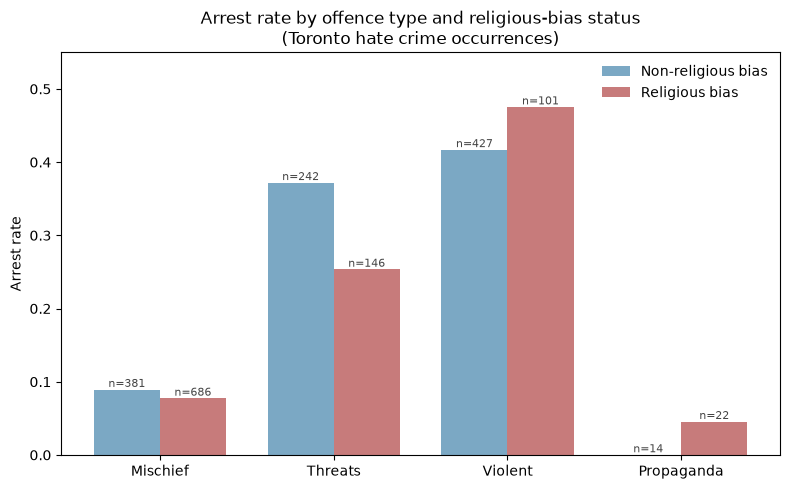

In [10]:
summary = (df.groupby(['offence_group', 'religion_bias'])['arrest']
             .agg(['mean', 'count']).reset_index())

groups = ['mischief', 'threats', 'violent', 'propaganda']
def vals(col, bias):
    return [summary[(summary.offence_group == g) & (summary.religion_bias == bias)][col].values[0]
            for g in groups]
rate0, rate1 = vals('mean', 0), vals('mean', 1)
n0, n1 = vals('count', 0), vals('count', 1)

x = np.arange(len(groups)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
b0 = ax.bar(x - w/2, rate0, w, label='Non-religious bias', color='#7BA8C4')
b1 = ax.bar(x + w/2, rate1, w, label='Religious bias', color='#C77B7B')
for bars, ns in [(b0, n0), (b1, n1)]:
    for bar, n in zip(bars, ns):
        ax.annotate(f'n={n}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8, color='#444')
ax.set_xticks(x); ax.set_xticklabels([g.capitalize() for g in groups])
ax.set_ylabel('Arrest rate'); ax.set_ylim(0, 0.55)
ax.set_title('Arrest rate by offence type and religious-bias status\n(Toronto hate crime occurrences)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Findings

**Raw gap.** Religious-bias hate crimes show a lower overall arrest rate (~15%) than non-religious-bias (~28%).

**Within offence type, the gap does not hold:**
- **Mischief** (n=381 / 686): rates nearly equal (8.9% vs 7.7%). Religious-bias incidents *concentrate* here — 686 of them, the largest and lowest-clearing group.
- **Violent** (n=427 / 101): religious-bias clears slightly *higher* (47.5% vs 41.7%).
- **Threats** (n=242 / 146): the gap persists (25.3% vs 37.2%) — the one exception.
- **Propaganda** (n=13 / 23): too small to interpret; excluded from conclusions.

**Interpretation.** The raw gap is largely explained by offence composition: religious-bias hate crimes skew heavily toward low-clearing mischief, which drives down their overall arrest rate. Within offence types there is no systematic arrest penalty against religious-bias crimes — the pattern is mixed (threats being the exception), not a uniform disadvantage. A reader citing the raw 15%-vs-28% gap as evidence of differential police response would be mistaken; the difference is mostly what kind of crime is being committed, not *how police respond to it.

**Limits.**
- Describes police response to incidents classified as hate crimes — not hate crime incidence, and not "bias."
- Arrest is one enforcement action; offence type is one confounder. Year, location, and investigative effort are uncontrolled.
- Several cells are small; propaganda is uninterpretable. The eyeball patterns above are formalized with confidence intervals in the regression (next step).

## 7. Logistic regression

The stratified table is suggestive but informal. To put a confidence interval on
it, we fit two logistic regressions of `arrest`:

1. **Model 1** — `religion_bias` alone (the raw association).
2. **Model 2** — `religion_bias` *plus* `offence_group` (controlling for offence type).

If the religion coefficient shrinks toward zero when offence type is added, the
raw gap is explained by composition. Coefficients are exponentiated to
odds ratios (OR): <1 = lower odds of arrest, >1 = higher, 1 = no effect.

In [11]:
import statsmodels.formula.api as smf
import numpy as np

# Model 1: raw association, no controls
m1 = smf.logit('arrest ~ religion_bias', data=df).fit(disp=0)
print('MODEL 1 — religion_bias alone')
print(m1.summary().tables[1])
print('OR:', round(np.exp(m1.params['religion_bias']), 3), '\n')

# Model 2: controlling for offence type
m2 = smf.logit('arrest ~ religion_bias + C(offence_group)', data=df).fit(disp=0)
print('MODEL 2 — controlling for offence type')
print(m2.summary().tables[1])
or2 = np.exp(m2.params['religion_bias'])
ci2 = np.exp(m2.conf_int().loc['religion_bias'])
print(f'OR: {or2:.3f}   95% CI [{ci2[0]:.3f}, {ci2[1]:.3f}]')

MODEL 1 — religion_bias alone
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.9255      0.068    -13.611      0.000      -1.059      -0.792
religion_bias    -0.8444      0.114     -7.394      0.000      -1.068      -0.621
OR: 0.43 

MODEL 2 — controlling for offence type
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -2.3298      0.138    -16.919      0.000      -2.600      -2.060
C(offence_group)[T.propaganda]    -1.1387      1.020     -1.116      0.264      -3.139       0.861
C(offence_group)[T.threats]        1.6636      0.159     10.457      0.000       1.352       1.975
C(offence_group)[T.violent]        2.0676      0.153     13.524      0.000       1.768       2.36

### Result

| | Religion-bias odds ratio | p-value | Interpretation |
|---|---|---|---|
| **Model 1** (no controls) | 0.43 | <0.001 | Religious-bias crimes ~half the odds of arrest |
| **Model 2** (+ offence type) | 0.86 | 0.26 | Effect not distinguishable from zero |

Controlling for offence type, the religion coefficient collapses from −0.84 to
−0.15, and its odds ratio (0.86) has a 95% CI of [0.67, 1.12] — crossing 1.0.
The apparent religious-bias arrest penalty does not survive the control.

In Model 2, the offence-type coefficients are large and significant (violent and
threats both clear far more than mischief), confirming that what kind of crime
occurred — not the religious-bias status — drives the arrest difference.

**Conclusion.** The raw association between religious bias and lower arrest
(OR 0.43, p<0.001) is explained by offence composition: religious-bias hate
crimes concentrate in low-clearing mischief. Once offence type is controlled,
there is no detectable difference in arrest rate by religious-bias status
(OR 0.86, 95% CI [0.67–1.12], p=0.26). This describes police *response* to
classified incidents, not hate crime incidence; offence type is one confounder
among several (year, location, investigative effort uncontrolled).